In [1]:
import numpy as np
import matplotlib.pyplot as plt

 Coin Design

In [2]:
H = (1 / np.sqrt(2)) * np.array([[1, 1],
                                 [1, -1]])

Quantum Walks

In [3]:
def quantum_walk(steps=100):

    size = 2 * steps + 1

    # Coin states
    psi_left = np.zeros(size, dtype=complex)
    psi_right = np.zeros(size, dtype=complex)

    center = steps

    # Initial coin state
    psi_left[center] = 1 / np.sqrt(2)
    psi_right[center] = 1j / np.sqrt(2)

    # Evolution
    for _ in range(steps):

        # Coin Operation
        left = H[0,0]*psi_left + H[0,1]*psi_right
        right = H[1,0]*psi_left + H[1,1]*psi_right

        # Shift Operation
        psi_left = np.roll(left, -1)     # Move left
        psi_right = np.roll(right, 1)    # Move right

        # Prevent wrap-around
        psi_left[-1] = 0
        psi_right[0] = 0

    probability = np.abs(psi_left)**2 + np.abs(psi_right)**2

    positions = np.arange(-steps, steps+1)

    return positions, probability

Ploting

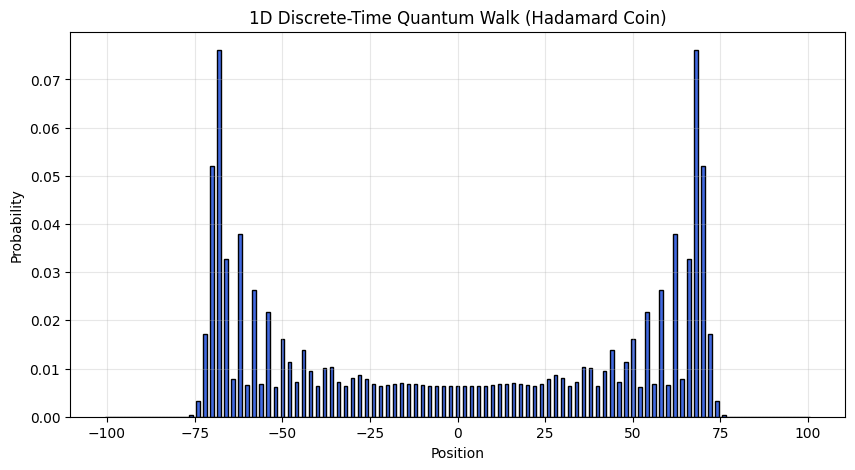

In [4]:

positions, probability = quantum_walk(steps=100)

plt.figure(figsize=(10,5))

plt.bar(positions,
        probability,
        width=1,
        color='royalblue',
        edgecolor='black')

plt.xlabel("Position")
plt.ylabel("Probability")
plt.title("1D Discrete-Time Quantum Walk (Hadamard Coin)")
plt.grid(alpha=0.3)

plt.show()